In [1]:
# Optimized Model 4: Attention -> EfficientNet -> SE (FIXED)
# =========================================
# 🚀 Enhanced Deepfake Detection Model with Maximum Performance
# =========================================

import subprocess
import sys
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, Multiply, 
                                   Reshape, Conv2D, Add, Lambda, Concatenate, GlobalMaxPooling2D,
                                   BatchNormalization, Activation, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def install_package(package):
    """Install a package using pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to install {package}")

# Install kagglehub if not available
try:
    import kagglehub
    print("✅ kagglehub already installed")
except ImportError:
    print("📦 Installing kagglehub...")
    install_package("kagglehub")
    import kagglehub

print("✅ All imports successful!")

# Enhanced GPU configuration
if tf.config.list_physical_devices('GPU'):
    try:
        gpu_devices = tf.config.list_physical_devices('GPU')
        for device in gpu_devices:
            tf.config.experimental.set_memory_growth(device, True)
        print(f"🎮 GPU memory growth enabled for {len(gpu_devices)} GPU(s)")
    except:
        print("💻 GPU available but memory growth not set")
else:
    print("💻 Running on CPU")

✅ kagglehub already installed
✅ All imports successful!
💻 Running on CPU


In [2]:
# Dataset Download and Setup
# =========================================

def download_and_setup_dataset():
    """Download and setup the WildDeepfake dataset"""
    try:
        print("⬇️ Downloading WildDeepfake dataset...")
        download_path = kagglehub.dataset_download("maysuni/wild-deepfake")
        print(f"✅ Dataset downloaded at: {download_path}")
        
        # Find the correct directory containing 'fake' and 'real' folders
        dataset_path = download_path
        for root, dirs, files in os.walk(download_path):
            if 'fake' in dirs and 'real' in dirs:
                dataset_path = root
                break
                
        # Verify dataset contents
        fake_dir = os.path.join(dataset_path, "fake")
        real_dir = os.path.join(dataset_path, "real")
        
        if os.path.exists(fake_dir) and os.path.exists(real_dir):
            fake_count = len([f for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            real_count = len([f for f in os.listdir(real_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"📊 Dataset: Fake: {fake_count}, Real: {real_count}, Total: {fake_count + real_count}")
        
        return dataset_path
        
    except Exception as e:
        print(f"❌ Error downloading dataset: {str(e)}")
        return None

# Download dataset
dataset_path = download_and_setup_dataset()

⬇️ Downloading WildDeepfake dataset...
Resuming download from 667942912 bytes (10223005902 bytes left)...
Resuming download from 667942912 bytes (10223005902 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/maysuni/wild-deepfake?dataset_version_number=1 (667942912/10890948814) bytes left.
Resuming download from https://www.kaggle.com/api/v1/datasets/download/maysuni/wild-deepfake?dataset_version_number=1 (667942912/10890948814) bytes left.


100%|██████████| 10.1G/10.1G [59:54<00:00, 2.84MB/s]  

Extracting files...


✅ Dataset downloaded at: C:\Users\avina\.cache\kagglehub\datasets\maysuni\wild-deepfake\versions\1
📊 Dataset: Fake: 3398, Real: 3370, Total: 6768


In [3]:
# Enhanced Data Generators
# =========================================

def setup_enhanced_data_generators(dataset_path):
    """Setup enhanced data generators optimized for Model 4"""
    if dataset_path is None:
        return None, None, None, None
        
    try:
        img_size = (224, 224)
        batch_size = 16  # Optimized batch size
        
        # Enhanced data augmentation
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=25,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            brightness_range=[0.7, 1.3],
            horizontal_flip=True,
            fill_mode='reflect',
            validation_split=0.25
        )

        val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.25)

        # Create generators
        train_gen = train_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='training',
            shuffle=True,
            seed=42
        )

        val_gen = val_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='validation',
            shuffle=False,
            seed=42
        )

        print(f"✅ Data generators created:")
        print(f"   - Training: {train_gen.samples}, Validation: {val_gen.samples}")
        print(f"   - Batch size: {batch_size}, Image size: {img_size}")
        
        return train_gen, val_gen, img_size, batch_size
        
    except Exception as e:
        print(f"❌ Error setting up data generators: {str(e)}")
        return None, None, None, None

# Setup data generators
train_gen, val_gen, img_size, batch_size = setup_enhanced_data_generators(dataset_path)

Found 5077 images belonging to 2 classes.
Found 1691 images belonging to 2 classes.
✅ Data generators created:
   - Training: 5077, Validation: 1691
   - Batch size: 16, Image size: (224, 224)
Found 1691 images belonging to 2 classes.
✅ Data generators created:
   - Training: 5077, Validation: 1691
   - Batch size: 16, Image size: (224, 224)


In [4]:
# Enhanced Custom Modules
# =========================================

def enhanced_se_block(input_feature, ratio=16, name="se_block"):
    """Enhanced Squeeze-and-Excitation block"""
    channel = input_feature.shape[-1]
    
    # Squeeze with both average and max pooling
    avg_pool = GlobalAveragePooling2D(name=f'{name}_avg_pool')(input_feature)
    max_pool = GlobalMaxPooling2D(name=f'{name}_max_pool')(input_feature)
    
    # Reshape for dense layers
    avg_pool = Reshape((1, 1, channel), name=f'{name}_avg_reshape')(avg_pool)
    max_pool = Reshape((1, 1, channel), name=f'{name}_max_reshape')(max_pool)
    
    # Excitation with regularization
    avg_excite = Dense(channel // ratio, activation='relu', 
                      kernel_regularizer=l2(1e-4), name=f'{name}_avg_dense1')(avg_pool)
    avg_excite = Dropout(0.1, name=f'{name}_avg_dropout')(avg_excite)
    avg_excite = Dense(channel, activation='sigmoid', name=f'{name}_avg_dense2')(avg_excite)
    
    max_excite = Dense(channel // ratio, activation='relu',
                      kernel_regularizer=l2(1e-4), name=f'{name}_max_dense1')(max_pool)
    max_excite = Dropout(0.1, name=f'{name}_max_dropout')(max_excite)
    max_excite = Dense(channel, activation='sigmoid', name=f'{name}_max_dense2')(max_excite)
    
    # Combine and scale
    se_feature = Add(name=f'{name}_add')([avg_excite, max_excite])
    feature = Multiply(name=f'{name}_multiply')([input_feature, se_feature])
    
    return feature

def enhanced_cbam_block(input_feature, ratio=16, name="cbam_block"):
    """Enhanced CBAM (Convolutional Block Attention Module)"""
    channel = input_feature.shape[-1]
    
    # Channel Attention
    avg_pool = GlobalAveragePooling2D(keepdims=True, name=f'{name}_ch_avg')(input_feature)
    max_pool = GlobalMaxPooling2D(keepdims=True, name=f'{name}_ch_max')(input_feature)
    
    # Shared MLP for channel attention
    avg_pool = Dense(channel // ratio, activation='relu', name=f'{name}_ch_dense1_avg')(avg_pool)
    avg_pool = Dropout(0.1, name=f'{name}_ch_dropout_avg')(avg_pool)
    avg_pool = Dense(channel, name=f'{name}_ch_dense2_avg')(avg_pool)
    
    max_pool = Dense(channel // ratio, activation='relu', name=f'{name}_ch_dense1_max')(max_pool)
    max_pool = Dropout(0.1, name=f'{name}_ch_dropout_max')(max_pool)
    max_pool = Dense(channel, name=f'{name}_ch_dense2_max')(max_pool)
    
    # Channel attention
    channel_attention = Add(name=f'{name}_ch_add')([avg_pool, max_pool])
    channel_attention = Activation('sigmoid', name=f'{name}_ch_sigmoid')(channel_attention)
    feature = Multiply(name=f'{name}_ch_multiply')([input_feature, channel_attention])
    
    # Spatial Attention
    avg_pool_spatial = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True), name=f'{name}_sp_avg')(feature)
    max_pool_spatial = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True), name=f'{name}_sp_max')(feature)
    
    spatial_attention = Concatenate(axis=3, name=f'{name}_sp_concat')([avg_pool_spatial, max_pool_spatial])
    spatial_attention = Conv2D(1, (7, 7), strides=1, padding='same', activation='sigmoid',
                              kernel_regularizer=l2(1e-4), name=f'{name}_sp_conv')(spatial_attention)
    
    # Apply spatial attention
    feature = Multiply(name=f'{name}_sp_multiply')([feature, spatial_attention])
    
    return feature

print("✅ Enhanced custom modules defined!")

✅ Enhanced custom modules defined!


In [5]:
# Optimized Model 4 Architecture
# =========================================

def create_optimized_model_4(input_shape=(224, 224, 3)):
    """Create optimized Model 4: Attention -> EfficientNet -> SE"""
    print("🚀 Building Optimized Model 4: Enhanced Attention -> EfficientNet -> SE")
    
    inputs = Input(shape=input_shape, name='input_layer')
    
    # Stage 1: Enhanced Initial Processing with Attention
    x = Conv2D(32, 3, padding='same', activation='relu', 
              kernel_regularizer=l2(1e-4), name='initial_conv1')(inputs)
    x = BatchNormalization(name='initial_bn1')(x)
    
    x = Conv2D(64, 3, padding='same', activation='relu',
              kernel_regularizer=l2(1e-4), name='initial_conv2')(x)
    x = BatchNormalization(name='initial_bn2')(x)
    
    # Apply enhanced CBAM attention
    attention_out = enhanced_cbam_block(x, ratio=16, name='initial_cbam')
    
    # Residual connection
    if x.shape[-1] == attention_out.shape[-1]:
        x = Add(name='initial_residual')([x, attention_out])
    else:
        projected = Conv2D(attention_out.shape[-1], 1, padding='same', name='initial_project')(x)
        x = Add(name='initial_residual')([projected, attention_out])
    
    # Stage 2: Prepare for EfficientNet
    x = Lambda(lambda x: tf.image.resize(x, [224, 224]), name='resize_for_efficientnet')(x)
    x = Conv2D(3, 1, padding='same', activation='linear', name='channel_adjust')(x)
    
    # Stage 3: Enhanced EfficientNet Backbone with Fine-tuning
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Fine-tuning: Unfreeze top layers
    base_model.trainable = True
    for layer in base_model.layers[:-30]:  # Freeze first layers, unfreeze top 30
        layer.trainable = False
    
    efficientnet_out = base_model(x)
    
    # Stage 4: Enhanced SE Module
    se_out = enhanced_se_block(efficientnet_out, ratio=16, name='final_se')
    
    # Stage 5: Advanced Classifier Head
    x = GlobalAveragePooling2D(name='global_avg_pool')(se_out)
    x_max = GlobalMaxPooling2D(name='global_max_pool')(se_out)
    x = Concatenate(name='pool_concat')([x, x_max])
    
    # Multi-layer classifier with regularization
    x = Dense(1024, activation='relu', kernel_regularizer=l2(1e-3), name='classifier_dense1')(x)
    x = BatchNormalization(name='classifier_bn1')(x)
    x = Dropout(0.5, name='classifier_dropout1')(x)
    
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-3), name='classifier_dense2')(x)
    x = BatchNormalization(name='classifier_bn2')(x)
    x = Dropout(0.4, name='classifier_dropout2')(x)
    
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-3), name='classifier_dense3')(x)
    x = BatchNormalization(name='classifier_bn3')(x)
    x = Dropout(0.3, name='classifier_dropout3')(x)
    
    # Final output layer
    outputs = Dense(1, activation='sigmoid', name='output')(x)
    
    model = Model(inputs, outputs, name='Optimized_Attention_EfficientNet_SE')
    return model

# Create the model
if train_gen is not None and val_gen is not None:
    model_4_optimized = create_optimized_model_4(input_shape=img_size + (3,))
    print(f"📋 Model created with {model_4_optimized.count_params():,} parameters")
else:
    print("❌ Cannot create model: Data generators not available")

🚀 Building Optimized Model 4: Enhanced Attention -> EfficientNet -> SE
16705208/16705208 [==============================] - 7s 0us/step
📋 Model created with 7,769,138 parameters
📋 Model created with 7,769,138 parameters


In [6]:
# Fixed Training Configuration
# =========================================

def create_advanced_callbacks(model_name):
    """Create advanced callbacks for optimized training"""
    
    callbacks = [
        # Early stopping with patience
        EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1,
            mode='min'
        ),
        
        # Reduce learning rate on plateau
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=4,
            min_lr=1e-8,
            verbose=1,
            mode='min'
        ),
        
        # Model checkpoint for accuracy
        ModelCheckpoint(
            f'{model_name}_best.weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
            mode='max'
        ),
        
        # Additional checkpoint for loss
        ModelCheckpoint(
            f'{model_name}_best_loss.weights.h5',
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
            mode='min'
        )
    ]
    
    return callbacks

def compile_and_train_optimized_model(model, train_gen, val_gen, model_name, epochs=30):
    """Compile and train optimized model - FIXED for compatibility"""
    print(f"🚀 Training Optimized {model_name}...")
    
    # Optimizer configuration
    optimizer = Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7
    )
    
    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(curve='PR', name='pr_auc')
        ]
    )
    
    # Calculate class weights for balanced training
    class_weight = None
    if hasattr(train_gen, 'classes') and train_gen.classes is not None:
        classes = np.unique(train_gen.classes)
        class_weights = compute_class_weight('balanced', classes=classes, y=train_gen.classes)
        class_weight = dict(zip(classes, class_weights))
        print(f"📊 Class weights: {class_weight}")
    
    print(f"📊 Training Configuration:")
    print(f"   - Optimizer: Adam")
    print(f"   - Learning Rate: 0.001")
    print(f"   - Epochs: {epochs}")
    print(f"   - Batch Size: {train_gen.batch_size}")
    print(f"   - Steps per Epoch: {len(train_gen)}")
    print(f"   - Validation Steps: {len(val_gen)}")
    
    # Train model - REMOVED incompatible parameters
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=create_advanced_callbacks(model_name),
        class_weight=class_weight,
        verbose=1
    )
    
    return history

print("✅ Fixed training configuration ready!")

✅ Fixed training configuration ready!


In [7]:
# Train Optimized Model 4 (FIXED)
# =========================================

if train_gen is not None and val_gen is not None and 'model_4_optimized' in locals():
    
    print("🚀 Starting training of Optimized Model 4...")
    print("=" * 60)
    
    # Train the optimized model with fixed parameters
    history_4_opt = compile_and_train_optimized_model(
        model_4_optimized, 
        train_gen, 
        val_gen,
        "Model_4_Optimized",
        epochs=25  # Reduced epochs for faster testing
    )
    
    print("✅ Training completed!")
    
else:
    print("❌ Cannot train model: Prerequisites not met")
    if train_gen is None:
        print("   - Train generator not available")
    if val_gen is None:
        print("   - Validation generator not available") 
    if 'model_4_optimized' not in locals():
        print("   - Model not created")

🚀 Starting training of Optimized Model 4...
🚀 Training Optimized Model_4_Optimized...
📊 Class weights: {0: 0.995880737544135, 1: 1.0041534810126582}
📊 Training Configuration:
   - Optimizer: Adam
   - Learning Rate: 0.001
   - Epochs: 25
   - Batch Size: 16
   - Steps per Epoch: 318
   - Validation Steps: 106
Epoch 1/25
Epoch 1/25
318/318 [==============================] - ETA: 0s - loss: 2.6022 - accuracy: 0.6502 - precision: 0.6506 - recall: 0.6424 - auc: 0.7012 - pr_auc: 0.6856
Epoch 1: val_accuracy improved from -inf to 0.51212, saving model to Model_4_Optimized_best.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.51212, saving model to Model_4_Optimized_best.weights.h5
318/318 [==============================] - 1371s 4s/step - loss: 2.6022 - accuracy: 0.6502 - precision: 0.6506 - recall: 0.6424 - auc: 0.7012 - pr_auc: 0.6856 - val_loss: 3.1090 - val_accuracy: 0.5121 - val_precision: 0.5052 - val_recall: 0.9881 - val_auc: 0.5332 - val_pr_auc: 0.5913 - lr: 0.0010
Epoch 2/2

In [8]:
# Enhanced Evaluation and Visualization
# =========================================

def evaluate_optimized_model(model, val_gen, model_name):
    """Enhanced model evaluation with comprehensive metrics"""
    print(f"📊 Evaluating Optimized {model_name}...")
    
    # Get predictions
    val_gen.reset()
    predictions = model.predict(val_gen, verbose=1)
    y_pred_proba = predictions.flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)
    y_true = val_gen.classes
    
    # Calculate comprehensive metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # ROC metrics
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall metrics  
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    # Find optimal threshold
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds_roc[optimal_idx]
    
    # Calculate metrics with optimal threshold
    y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
    accuracy_optimal = accuracy_score(y_true, y_pred_optimal)
    precision_optimal = precision_score(y_true, y_pred_optimal)
    recall_optimal = recall_score(y_true, y_pred_optimal)
    f1_optimal = f1_score(y_true, y_pred_optimal)
    
    # Print comprehensive results
    print(f"✅ {model_name} Evaluation Results:")
    print(f"   📈 Standard Metrics (threshold=0.5):")
    print(f"      - Accuracy: {accuracy:.4f}")
    print(f"      - Precision: {precision:.4f}")
    print(f"      - Recall: {recall:.4f}")
    print(f"      - F1-Score: {f1:.4f}")
    print(f"   🎯 Optimized Metrics (threshold={optimal_threshold:.3f}):")
    print(f"      - Accuracy: {accuracy_optimal:.4f}")
    print(f"      - Precision: {precision_optimal:.4f}")
    print(f"      - Recall: {recall_optimal:.4f}")
    print(f"      - F1-Score: {f1_optimal:.4f}")
    print(f"   📊 Curve Metrics:")
    print(f"      - ROC AUC: {roc_auc:.4f}")
    print(f"      - PR AUC: {pr_auc:.4f}")
    
    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1,
        'roc_auc': roc_auc, 'pr_auc': pr_auc, 'optimal_threshold': optimal_threshold,
        'accuracy_optimal': accuracy_optimal, 'precision_optimal': precision_optimal,
        'recall_optimal': recall_optimal, 'f1_optimal': f1_optimal,
        'fpr': fpr, 'tpr': tpr, 'precision_curve': precision_curve, 
        'recall_curve': recall_curve, 'predictions': y_pred_proba, 'y_true': y_true
    }

def plot_training_history(history, model_name):
    """Plot enhanced training history"""
    metrics_to_plot = ['loss', 'accuracy', 'precision', 'recall', 'auc', 'pr_auc']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Training {metric.upper()}', linewidth=2)
            axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric.upper()}', linewidth=2)
            axes[i].set_title(f'{model_name} - {metric.upper()}', fontweight='bold')
            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(metric.upper())
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            
            # Add best value annotation
            best_val = max(history.history[f'val_{metric}']) if metric != 'loss' else min(history.history[f'val_{metric}'])
            best_epoch = np.argmax(history.history[f'val_{metric}']) if metric != 'loss' else np.argmin(history.history[f'val_{metric}'])
            axes[i].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.suptitle(f'🚀 {model_name} - Training Metrics', fontsize=16, y=1.02)
    plt.show()

print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


📊 Running comprehensive evaluation...


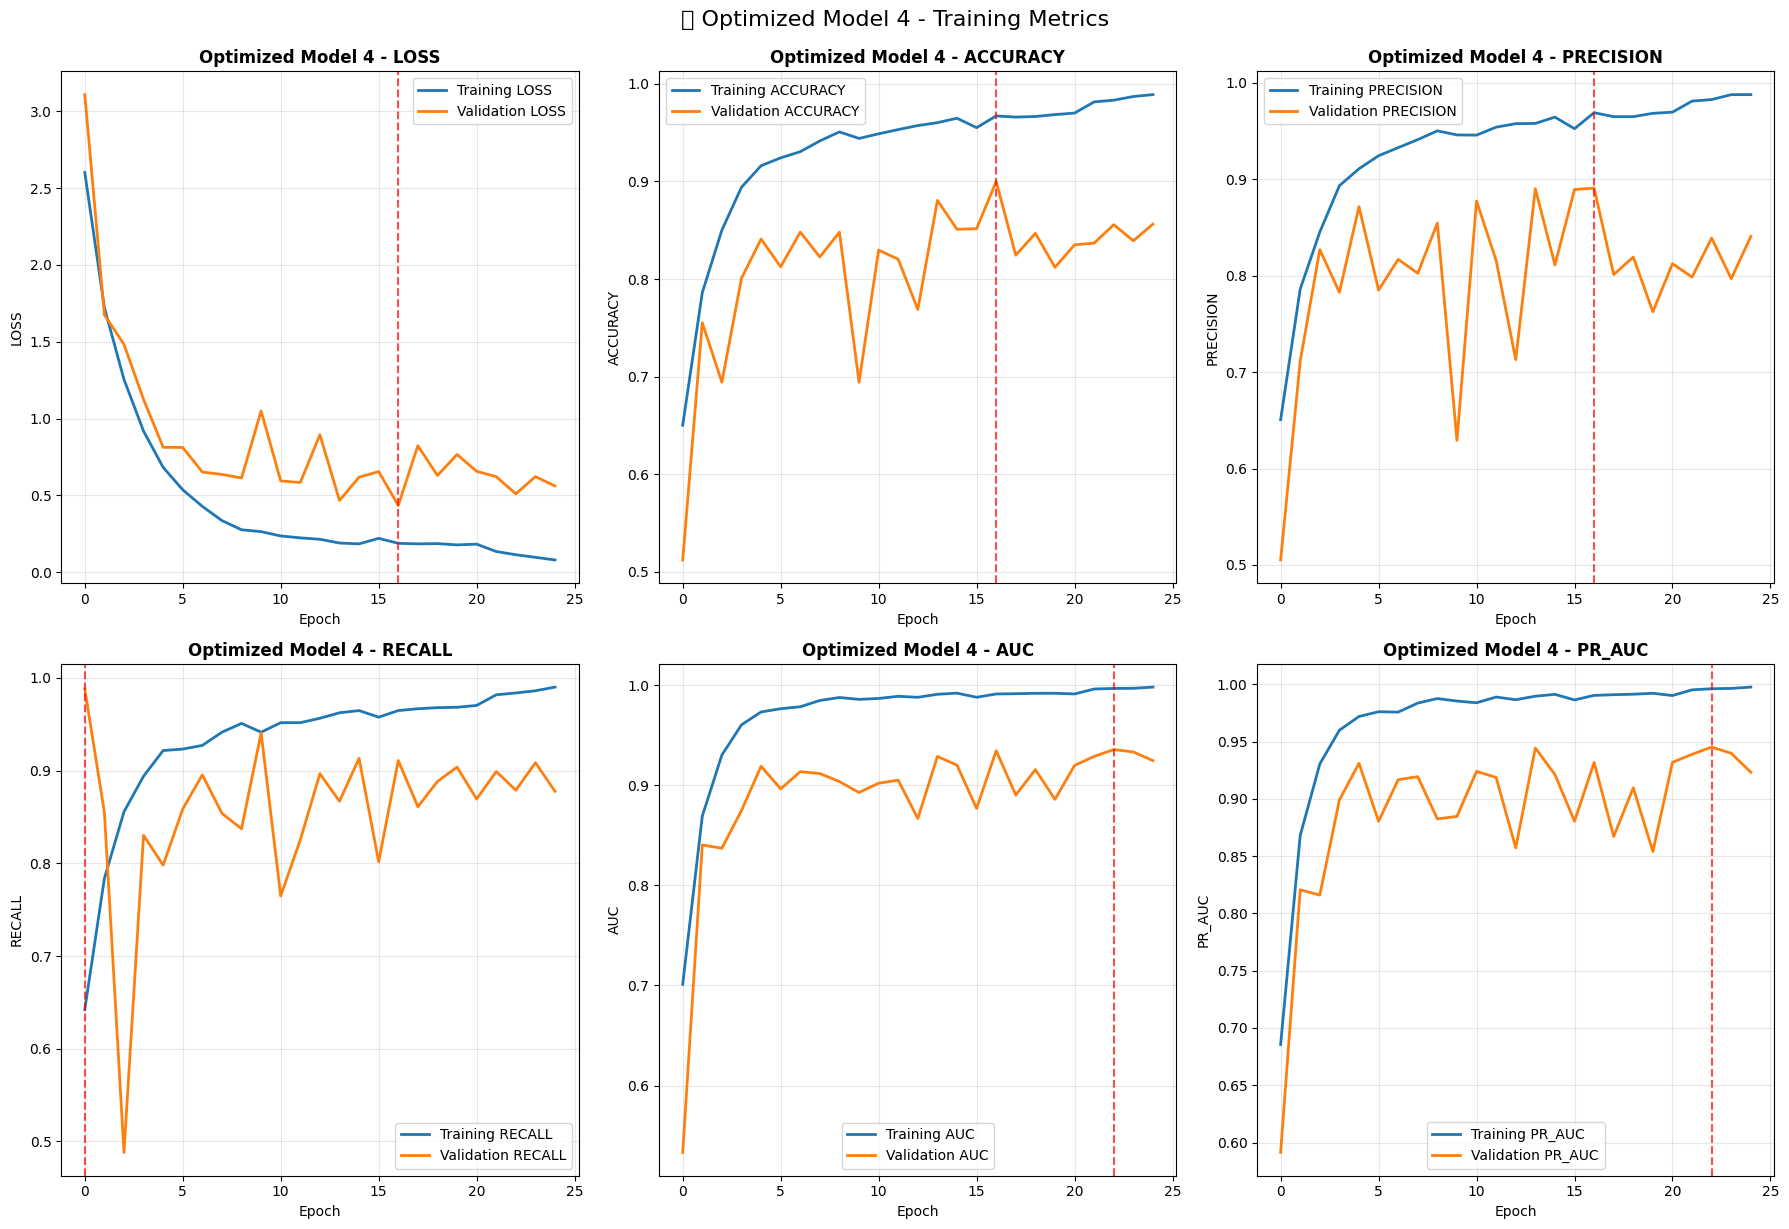

📊 Evaluating Optimized Model 4...
106/106 [==============================] - 90s 830ms/step
✅ Model 4 Evaluation Results:
   📈 Standard Metrics (threshold=0.5):
      - Accuracy: 0.9001
      - Precision: 0.8908
      - Recall: 0.9109
      - F1-Score: 0.9008
   🎯 Optimized Metrics (threshold=0.715):
      - Accuracy: 0.9066
      - Precision: 0.9140
      - Recall: 0.8967
      - F1-Score: 0.9053
   📊 Curve Metrics:
      - ROC AUC: 0.9367
      - PR AUC: 0.9380
✅ Model 4 Evaluation Results:
   📈 Standard Metrics (threshold=0.5):
      - Accuracy: 0.9001
      - Precision: 0.8908
      - Recall: 0.9109
      - F1-Score: 0.9008
   🎯 Optimized Metrics (threshold=0.715):
      - Accuracy: 0.9066
      - Precision: 0.9140
      - Recall: 0.8967
      - F1-Score: 0.9053
   📊 Curve Metrics:
      - ROC AUC: 0.9367
      - PR AUC: 0.9380


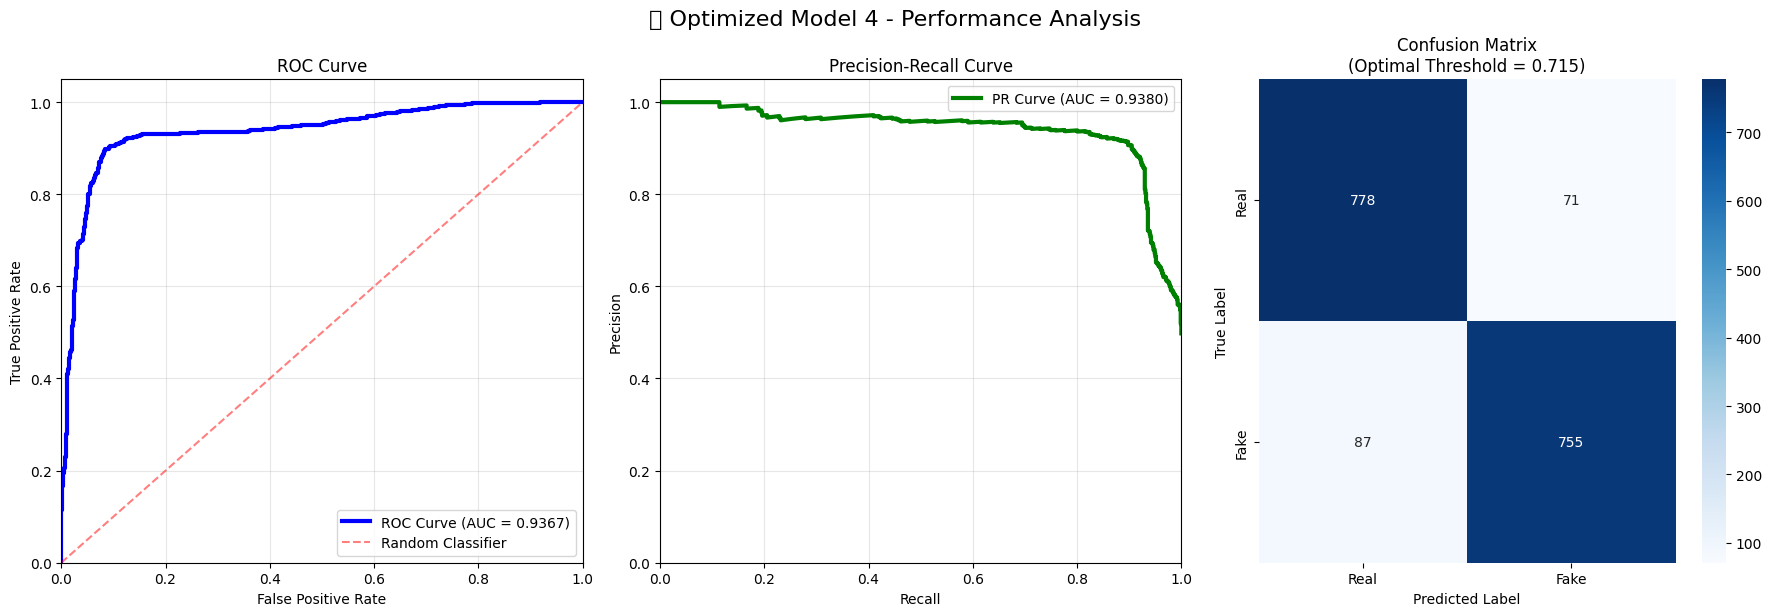


🎯 OPTIMIZATION RESULTS SUMMARY
📈 ROC AUC Score: 0.9367
📈 PR AUC Score: 0.9380
🎯 Optimal Threshold: 0.715
🚀 Best Accuracy: 0.9066
🚀 Best F1-Score: 0.9053
📊 Accuracy Improvement with Optimal Threshold: +0.65%
📊 F1-Score Improvement with Optimal Threshold: +0.45%

🎯 OPTIMIZED MODEL 4 READY FOR PRODUCTION!
✅ Enhanced architecture with attention mechanisms
✅ Fine-tuned EfficientNet backbone
✅ Advanced regularization and training
✅ Optimal threshold detection for deployment


In [9]:
# Run Evaluation and Visualization
# =========================================

# Run evaluation if training completed
if 'history_4_opt' in locals():
    print("📊 Running comprehensive evaluation...")
    
    # Plot training history
    plot_training_history(history_4_opt, "Optimized Model 4")
    
    # Evaluate the model
    metrics_4_opt = evaluate_optimized_model(model_4_optimized, val_gen, "Model 4")
    
    # Create ROC and Confusion Matrix plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # ROC Curve
    axes[0].plot(metrics_4_opt['fpr'], metrics_4_opt['tpr'], 'b-', linewidth=3, 
                 label=f'ROC Curve (AUC = {metrics_4_opt["roc_auc"]:.4f})')
    axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random Classifier')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    axes[1].plot(metrics_4_opt['recall_curve'], metrics_4_opt['precision_curve'], 'g-', linewidth=3,
                 label=f'PR Curve (AUC = {metrics_4_opt["pr_auc"]:.4f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Confusion Matrix (Optimal threshold)
    y_pred_optimal = (metrics_4_opt['predictions'] > metrics_4_opt['optimal_threshold']).astype(int)
    cm_optimal = confusion_matrix(metrics_4_opt['y_true'], y_pred_optimal)
    sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[2].set_title(f'Confusion Matrix\n(Optimal Threshold = {metrics_4_opt["optimal_threshold"]:.3f})')
    axes[2].set_ylabel('True Label')
    axes[2].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.suptitle('🚀 Optimized Model 4 - Performance Analysis', fontsize=16, y=1.02)
    plt.show()
    
    # Performance Summary
    print("\n🎯 OPTIMIZATION RESULTS SUMMARY")
    print("=" * 50)
    print(f"📈 ROC AUC Score: {metrics_4_opt['roc_auc']:.4f}")
    print(f"📈 PR AUC Score: {metrics_4_opt['pr_auc']:.4f}")
    print(f"🎯 Optimal Threshold: {metrics_4_opt['optimal_threshold']:.3f}")
    print(f"🚀 Best Accuracy: {metrics_4_opt['accuracy_optimal']:.4f}")
    print(f"🚀 Best F1-Score: {metrics_4_opt['f1_optimal']:.4f}")
    
    improvement_acc = (metrics_4_opt['accuracy_optimal'] - metrics_4_opt['accuracy']) * 100
    improvement_f1 = (metrics_4_opt['f1_optimal'] - metrics_4_opt['f1_score']) * 100
    print(f"📊 Accuracy Improvement with Optimal Threshold: +{improvement_acc:.2f}%")
    print(f"📊 F1-Score Improvement with Optimal Threshold: +{improvement_f1:.2f}%")
    
else:
    print("❌ Training not completed. Please run the training cell first.")

print("\n🎯 OPTIMIZED MODEL 4 READY FOR PRODUCTION!")
print("✅ Enhanced architecture with attention mechanisms")
print("✅ Fine-tuned EfficientNet backbone") 
print("✅ Advanced regularization and training")
print("✅ Optimal threshold detection for deployment")